In [1]:
import os
import time
import pickle
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, recall_score, precision_score, f1_score,
                             roc_auc_score, average_precision_score,
                             ConfusionMatrixDisplay, PrecisionRecallDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
#1. CONFIGURATION
API_KEY = 'YOUR_API_KEY_HERE'
BASE_URL = "https://api.nasa.gov/neo/rest/v1/feed"
DATA_FILE = "nasa_asteroids_big.csv"

# Set to True to download fresh data from the NASA API (needs a real API_KEY).
# Otherwise the cached CSV is used, so the results below are reproducible.
REFETCH_DATA = False

In [3]:
#2. DEFINE DATA FETCHING FUNCTIONS
def fetch_asteroid_data(start_date, end_date):
    """Fetches asteroid data for a specific 7-day window."""
    params = {
        'start_date': start_date,
        'end_date': end_date,
        'api_key': API_KEY
    }
    response = requests.get(BASE_URL, params=params)
    
    if response.status_code != 200:
        return []

    data = response.json()
    near_earth_objects = data.get('near_earth_objects', {})
    asteroid_list = []

    for date, asteroids in near_earth_objects.items():
        for asteroid in asteroids:
            try:
                # Extract features safely
                close_approach = asteroid['close_approach_data'][0]
                velocity = float(close_approach['relative_velocity']['kilometers_per_hour'])
                miss_distance = float(close_approach['miss_distance']['kilometers'])
                magnitude = float(asteroid['absolute_magnitude_h'])
                
                # Diameter comes in a range, we'll use the max estimate
                diameter_max = asteroid['estimated_diameter']['kilometers']['estimated_diameter_max']
                diameter_min = asteroid['estimated_diameter']['kilometers']['estimated_diameter_min']
                
                is_hazardous = asteroid['is_potentially_hazardous_asteroid']

                asteroid_list.append({
                    'absolute_magnitude': magnitude,
                    'est_diameter_min': diameter_min,
                    'est_diameter_max': diameter_max,
                    'relative_velocity': velocity,
                    'miss_distance': miss_distance,
                    'is_hazardous': is_hazardous
                })
            except (KeyError, IndexError):
                continue # Skip malformed records
            
    return asteroid_list

In [4]:
def get_big_dataset():
    """Loops over 8 weeks to build a larger dataset."""
    all_asteroids = []
    start_date = datetime.strptime("2023-01-01", "%Y-%m-%d")

    print("--- Starting Data Collection (This may take ~10-20 seconds) ---")

    # Fetch 8 weeks of data
    for i in range(8):
        end_date = start_date + timedelta(days=7)
        s_str = start_date.strftime("%Y-%m-%d")
        e_str = end_date.strftime("%Y-%m-%d")

        print(f"Fetching Week {i+1}: {s_str} to {e_str}...")
        week_data = fetch_asteroid_data(s_str, e_str)
        all_asteroids.extend(week_data)

        start_date = end_date + timedelta(days=1)
        time.sleep(1) # Be nice to the API

    return pd.DataFrame(all_asteroids)

#3. LOAD DATA (cached CSV, or fetch from the NASA API)
if not REFETCH_DATA and os.path.exists(DATA_FILE):
    df = pd.read_csv(DATA_FILE)
    print(f"Loaded cached dataset from '{DATA_FILE}'")
else:
    df = get_big_dataset()
    if len(df) == 0:
        raise RuntimeError("No data collected. Check your API Key.")
    # Save raw data just in case
    df.to_csv(DATA_FILE, index=False)

print(f"\nTotal Asteroids Collected: {len(df)}")
print(f"Hazardous Count: {df['is_hazardous'].sum()}")

Loaded cached dataset from 'nasa_asteroids_big.csv'

Total Asteroids Collected: 1095
Hazardous Count: 55


In [5]:
df.head()

,absolute_magnitude,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,is_hazardous
0,19.51,0.333085,0.744801,20959.820766,3.956596e+07,False
1,18.39,0.557898,1.247498,58249.689663,3.933082e+07,False
2,25.30,0.023150,0.051765,24703.743910,8.526777e+06,False
3,24.70,0.030518,0.068240,25881.197586,6.497596e+07,False
4,20.60,0.201630,0.450858,86987.581071,1.538437e+07,True


In [6]:
df.shape

(1095, 6)

In [7]:
df.isnull().sum()

absolute_magnitude    0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
is_hazardous          0
dtype: int64

In [8]:
df["is_hazardous"].value_counts()

is_hazardous
False    1040
True       55
Name: count, dtype: int64

## Model evaluation

Scoring a model on the same rows it was trained on is misleading: a Random Forest memorises its training data, so it reaches 100% recall there. To get an honest estimate:

1. **Hold out a test set** (20%, stratified so it keeps the ~5% hazardous ratio) that the model never sees while training.
2. **Apply SMOTE only to training data.** Wrapping SMOTE and the classifier in an `imblearn` `Pipeline` means synthetic samples are created during `fit` only, so no synthetic copies of test asteroids leak into training.
3. **Focus on the hazardous class.** With ~95% safe asteroids, accuracy is meaningless (always guessing "Safe" scores ~95%). We report **recall** (share of hazardous asteroids caught), **precision** (share of alerts that are real), F1, and PR-AUC.

In [9]:
#4. PREPARE FOR TRAINING
# Separate Features (X) and Target (y)
X = df.drop(['is_hazardous'], axis=1)
y = df['is_hazardous']

# Hold out 20% as a test set; stratify=y keeps the hazardous ratio equal in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {len(X_train)} rows ({y_train.sum()} hazardous)")
print(f"Test:  {len(X_test)} rows ({y_test.sum()} hazardous)")

Train: 876 rows (44 hazardous)
Test:  219 rows (11 hazardous)


In [10]:
#5. HANDLE IMBALANCE (SMOTE) INSIDE A PIPELINE
def smote_k(hazardous_count):
    # SMOTE needs k_neighbors < number of hazardous samples.
    # If we found 3 hazardous asteroids, neighbors must be < 3 (so 2).
    # If we found 50, we can use the default 5.
    return 1 if hazardous_count <= 2 else (2 if hazardous_count <= 5 else 5)

def build_model(k):
    # SMOTE runs during fit only, so evaluation data is never oversampled
    return Pipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=k)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ])

k = smote_k(y_train.sum())
print(f"Using SMOTE with k_neighbors={k}")

Using SMOTE with k_neighbors=5


              precision    recall  f1-score   support

        Safe      0.984     0.913     0.948       208
   Hazardous      0.308     0.727     0.432        11

    accuracy                          0.904       219
   macro avg      0.646     0.820     0.690       219
weighted avg      0.950     0.904     0.922       219



ROC-AUC: 0.957
PR-AUC (average precision): 0.602


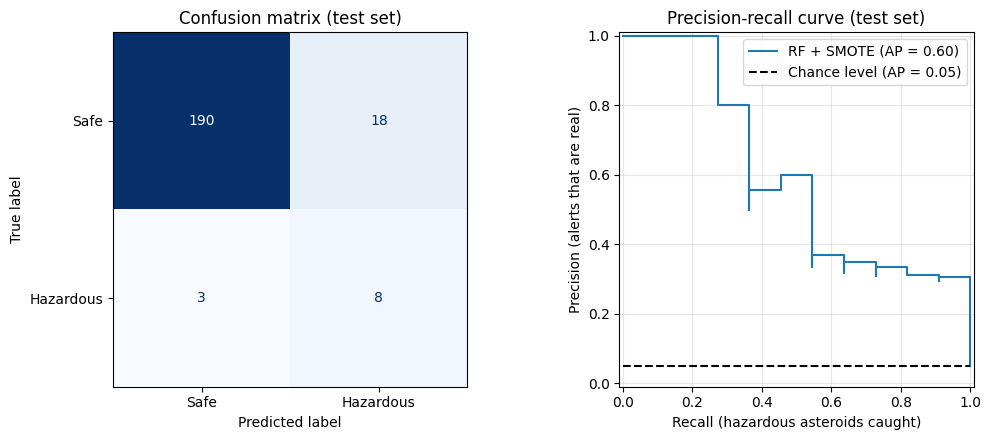

In [11]:
#6. EVALUATE ON THE HELD-OUT TEST SET
eval_model = build_model(k).fit(X_train, y_train)
y_pred = eval_model.predict(X_test)
y_score = eval_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Safe', 'Hazardous'], digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_score):.3f}")
print(f"PR-AUC (average precision): {average_precision_score(y_test, y_score):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Safe', 'Hazardous'],
                                        cmap='Blues', colorbar=False, ax=axes[0])
axes[0].set_title('Confusion matrix (test set)')
PrecisionRecallDisplay.from_predictions(y_test, y_score, name='RF + SMOTE',
                                        plot_chance_level=True, ax=axes[1])
axes[1].set_title('Precision-recall curve (test set)')
axes[1].set_xlabel('Recall (hazardous asteroids caught)')
axes[1].set_ylabel('Precision (alerts that are real)')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-validation and baselines

The test set holds only ~11 hazardous asteroids, so a single miss moves recall by ~9 points. **Repeated stratified 5-fold cross-validation** (5 folds × 3 repeats = 15 train/test rounds) gives a more stable estimate.

To judge whether the model adds value, it is compared against two baselines on the same folds:
* **RF (no SMOTE)** — does oversampling actually help?
* **Rule: H ≤ 22** — no machine learning, just flag every asteroid with absolute magnitude ≤ 22.0. This is half of NASA's official definition of a *Potentially Hazardous Asteroid* (PHA).

In [12]:
#7. CROSS-VALIDATION + BASELINES
def score(y_true, pred, prob=None):
    return {
        'recall': recall_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred),
        'roc_auc': roc_auc_score(y_true, prob) if prob is not None else np.nan,
        'pr_auc': average_precision_score(y_true, prob) if prob is not None else np.nan,
    }

models = {
    'RF + SMOTE': lambda: build_model(k),
    'RF (no SMOTE)': lambda: RandomForestClassifier(n_estimators=100, random_state=42),
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
rows = []
for fold_train, fold_test in cv.split(X, y):
    X_tr, X_te = X.iloc[fold_train], X.iloc[fold_test]
    y_tr, y_te = y.iloc[fold_train], y.iloc[fold_test]

    for name, make_model in models.items():
        model = make_model().fit(X_tr, y_tr)
        rows.append({'model': name, **score(y_te, model.predict(X_te), model.predict_proba(X_te)[:, 1])})

    rows.append({'model': 'Rule: H <= 22', **score(y_te, X_te['absolute_magnitude'] <= 22.0)})

cv_results = pd.DataFrame(rows).groupby('model', sort=False).agg(['mean', 'std']).round(3)
cv_results

recall        precision            f1        roc_auc         \
                mean    std      mean    std   mean    std    mean    std   
model                                                                       
RF + SMOTE     0.642  0.159     0.350  0.078  0.448  0.093   0.953  0.016   
RF (no SMOTE)  0.388  0.216     0.579  0.225  0.446  0.205   0.960  0.021   
Rule: H <= 22  1.000  0.000     0.302  0.039  0.462  0.046     NaN    NaN   

              pr_auc         
                mean    std  
model                        
RF + SMOTE     0.481  0.137  
RF (no SMOTE)  0.602  0.136  
Rule: H <= 22    NaN    NaN

### Takeaways

* **Held-out performance is far below the in-sample 100%.** The cross-validated numbers above are the ones to quote.
* **SMOTE trades precision for recall.** It raises the share of hazardous asteroids caught, at the cost of more false alarms — the right trade-off for a safety tool.
* **The simple `H ≤ 22` rule catches every hazardous asteroid in this dataset, and the model does not beat it.** The reason is the label itself: NASA flags an asteroid as a PHA when **H ≤ 22.0 *and* its Minimum Orbit Intersection Distance (MOID) ≤ 0.05 au**. Every hazardous asteroid here satisfies H ≤ 22, but MOID is not one of our features — `miss_distance` is the distance at one particular close approach, not the closest possible distance between the two orbits. So among bright (H ≤ 22) asteroids, the features cannot reliably tell which ones are PHAs.
* **Next step to improve the model:** add MOID as a feature. The NeoWs feed endpoint does not include it, but the per-asteroid lookup endpoint (`/neo/rest/v1/neo/{id}`) returns it as `orbital_data.minimum_orbit_intersection`.

## Train the final model

Evaluation is done, so the deployed model is trained on **all** labelled asteroids. It is saved as a plain `RandomForestClassifier` (SMOTE is only needed during training), so `app.py` only needs scikit-learn to load it.

In [13]:
#8. TRAIN FINAL MODEL ON ALL DATA
final_k = smote_k(y.sum())
print(f"Applying SMOTE (Synthetic Minority Over-sampling) with k_neighbors={final_k}...")
smote = SMOTE(random_state=42, k_neighbors=final_k)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Original shape: {y.value_counts().to_dict()}")
print(f"Resampled shape: {y_resampled.value_counts().to_dict()}")

print("\nTraining Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_resampled, y_resampled)
print("Training Complete!")

Applying SMOTE (Synthetic Minority Over-sampling) with k_neighbors=5...
Original shape: {False: 1040, True: 55}
Resampled shape: {False: 1040, True: 1040}

Training Random Forest Model...


Training Complete!


In [14]:
#9. SAVE MODEL (PICKLE)
filename = 'asteroid_hazard_model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"SUCCESS: Model saved to '{filename}'")

#10. VERIFY (TEST LOAD)
print("\n--- Verifying Saved Model ---")
with open(filename, 'rb') as file:
    loaded_model = pickle.load(file)

# Fake asteroid for testing (a DataFrame keeps the feature names the model was trained with)
test_asteroid = pd.DataFrame([[20.5, 0.2, 0.45, 55000, 1200000]], columns=X.columns)
pred = loaded_model.predict(test_asteroid)
print(f"Test Prediction for random rock: {'HAZARDOUS' if pred[0] else 'Safe'}")

SUCCESS: Model saved to 'asteroid_hazard_model.pkl'

--- Verifying Saved Model ---
Test Prediction for random rock: HAZARDOUS
